In [1]:
from codebase.utils_ml import *
from sklearn.feature_selection import VarianceThreshold

In [2]:
# X_arr = np.load('data/nfeatures_08/features_filtered.npy', mmap_mode='r+')
# sel = VarianceThreshold(threshold=(.9 * (1 - .9)))
# X_arr = sel.fit_transform(X_arr)

# np.save('data/features_selected.npy',X_arr)

In [3]:
X_arr = np.load('data/features_selected.npy', mmap_mode='r+')

In [4]:
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

y_arr_classification = np.array([np.tile(i,24000//8) for i in np.arange(0,8)]).flatten() #[inlier_mask]
y_arr_regression = convert_labels(y_arr_classification, class_to_poles)*1.0 #[inlier_mask]

In [5]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression

# Define the base CatBoostRegressor model
def create_catboost_model():
    return CatBoostRegressor(
        verbose=1000,
        loss_function="RMSE",
        depth=6
    )

# # Split the dataset
X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_regression, random_state=42, test_size=0.2)
preds = []
for i in tqdm(range(y_train.shape[1])):
    # Create three CatBoostRegressor models
    model1 = create_catboost_model()
    model2 = create_catboost_model()
    model3 = create_catboost_model()

    # Train the individual models
    model1.fit(X_train, y_train[:,i], eval_set=(X_val, y_val[:,i]), plot=False)
    model2.fit(X_train, y_train[:,i], eval_set=(X_val, y_val[:,i]), plot=False)
    model3.fit(X_train, y_train[:,i], eval_set=(X_val, y_val[:,i]), plot=False)

    # Voting Regressor (averages predictions from all models)
    voting_regressor = VotingRegressor(estimators=[
        ('cb1', model1),
        ('cb2', model2),
        ('cb3', model3)
    ])

    # Train the Voting Regressor
    voting_regressor.fit(X_train, y_train[:,i])

    # Evaluate Voting Regressor
    voting_predictions = voting_regressor.predict(X_val)
    print("Voting Regressor Predictions:")
    print(voting_predictions)
    preds.append(voting_predictions)

preds = np.column_stack(preds)



  0%|          | 0/3 [00:00<?, ?it/s]

Learning rate set to 0.080979
0:	learn: 0.4573852	test: 0.4550269	best: 0.4550269 (0)	total: 80.2ms	remaining: 1m 20s
999:	learn: 0.0588717	test: 0.1306509	best: 0.1306478 (998)	total: 35.8s	remaining: 0us

bestTest = 0.1306478496
bestIteration = 998

Shrink model to first 999 iterations.
Learning rate set to 0.080979
0:	learn: 0.4573852	test: 0.4550269	best: 0.4550269 (0)	total: 33.6ms	remaining: 33.5s
999:	learn: 0.0588717	test: 0.1306509	best: 0.1306478 (998)	total: 36s	remaining: 0us

bestTest = 0.1306478496
bestIteration = 998

Shrink model to first 999 iterations.
Learning rate set to 0.080979
0:	learn: 0.4573852	test: 0.4550269	best: 0.4550269 (0)	total: 32.1ms	remaining: 32.1s
999:	learn: 0.0588717	test: 0.1306509	best: 0.1306478 (998)	total: 37.4s	remaining: 0us

bestTest = 0.1306478496
bestIteration = 998

Shrink model to first 999 iterations.
Learning rate set to 0.065304
0:	learn: 0.4626081	total: 39.9ms	remaining: 39.9s
999:	learn: 0.0683884	total: 38.5s	remaining: 0us
Lea

 33%|███▎      | 1/3 [04:03<08:07, 243.85s/it]

Voting Regressor Predictions:
[ 0.00951469 -0.00450694  1.01496015 ...  0.01319787  1.00180604
 -0.00404759]
Learning rate set to 0.080979
0:	learn: 0.5655439	test: 0.5625633	best: 0.5625633 (0)	total: 32.8ms	remaining: 32.7s
999:	learn: 0.0968024	test: 0.1764389	best: 0.1764389 (999)	total: 39.9s	remaining: 0us

bestTest = 0.1764389177
bestIteration = 999

Learning rate set to 0.080979
0:	learn: 0.5655439	test: 0.5625633	best: 0.5625633 (0)	total: 33.3ms	remaining: 33.2s
999:	learn: 0.0968024	test: 0.1764389	best: 0.1764389 (999)	total: 37.2s	remaining: 0us

bestTest = 0.1764389177
bestIteration = 999

Learning rate set to 0.080979
0:	learn: 0.5655439	test: 0.5625633	best: 0.5625633 (0)	total: 30.4ms	remaining: 30.4s
999:	learn: 0.0968024	test: 0.1764389	best: 0.1764389 (999)	total: 41.4s	remaining: 0us

bestTest = 0.1764389177
bestIteration = 999

Learning rate set to 0.065304
0:	learn: 0.5721901	total: 35.3ms	remaining: 35.2s
999:	learn: 0.1082375	total: 38.6s	remaining: 0us
Learnin

 67%|██████▋   | 2/3 [08:08<04:04, 244.21s/it]

Voting Regressor Predictions:
[ 0.99726122  1.86688723  1.02696662 ...  1.00026425 -0.00354642
  0.96705321]
Learning rate set to 0.080979
0:	learn: 0.6312419	test: 0.6345104	best: 0.6345104 (0)	total: 32.7ms	remaining: 32.6s
999:	learn: 0.1396924	test: 0.2444042	best: 0.2443898 (998)	total: 36.1s	remaining: 0us

bestTest = 0.2443897556
bestIteration = 998

Shrink model to first 999 iterations.
Learning rate set to 0.080979
0:	learn: 0.6312419	test: 0.6345104	best: 0.6345104 (0)	total: 31.4ms	remaining: 31.4s
999:	learn: 0.1396924	test: 0.2444042	best: 0.2443898 (998)	total: 34.6s	remaining: 0us

bestTest = 0.2443897556
bestIteration = 998

Shrink model to first 999 iterations.
Learning rate set to 0.080979
0:	learn: 0.6312419	test: 0.6345104	best: 0.6345104 (0)	total: 30.7ms	remaining: 30.7s
999:	learn: 0.1396924	test: 0.2444042	best: 0.2443898 (998)	total: 34.4s	remaining: 0us

bestTest = 0.2443897556
bestIteration = 998

Shrink model to first 999 iterations.
Learning rate set to 0.0

100%|██████████| 3/3 [11:49<00:00, 236.57s/it]

Voting Regressor Predictions:
[-0.03144317  1.15096472  1.05588887 ... -0.00744603  0.00654312
  0.97888504]


In [6]:

accuracy_score(reconvert_labels(np.abs(np.round(preds)), class_to_poles), reconvert_labels(y_val, class_to_poles))


0.8991666666666667

In [7]:
stop

NameError: name 'stop' is not defined

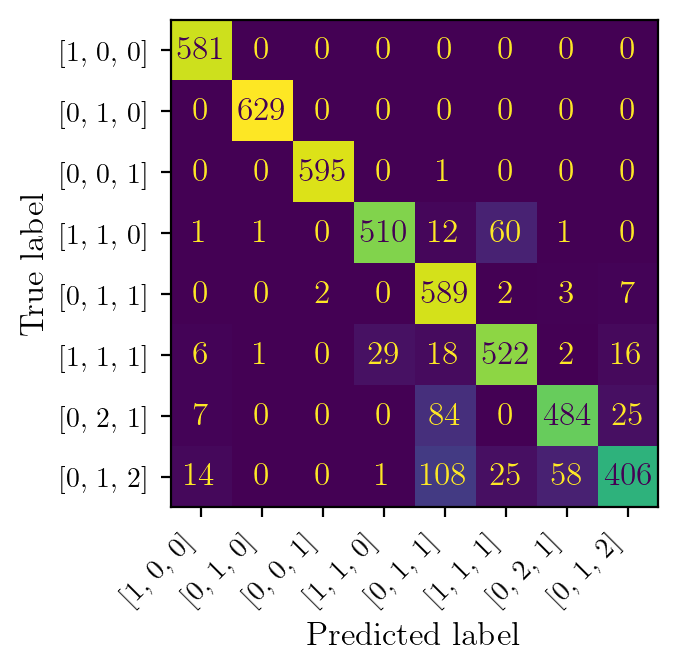

In [11]:
# Custom class-to-poles mapping
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

# Custom labels for the axes
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Aggregate predictions over the folds

custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Compute the confusion matrix
cm = confusion_matrix(reconvert_labels(y_val, class_to_poles), reconvert_labels(np.abs(np.round(preds)), class_to_poles), labels=np.arange(len(class_to_poles)))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(3.54331, 3.54331))  # Adjust figure size if needed
disp.plot(ax=ax,colorbar=False)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()

In [7]:
stop

NameError: name 'stop' is not defined

In [41]:
rg = CatBoostRegressor(
    verbose=100,
    loss_function="MultiRMSE",
    depth=6
    )
X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_regression, random_state=42, test_size=0.2)
rg.fit(X_train, y_train, eval_set=(X_val,y_val),plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.9953712	test: 0.9881166	best: 0.9881166 (0)	total: 380ms	remaining: 6m 19s
100:	learn: 0.4477181	test: 0.4579583	best: 0.4579583 (100)	total: 38.4s	remaining: 5m 41s
200:	learn: 0.3915295	test: 0.4148352	best: 0.4148352 (200)	total: 1m 15s	remaining: 4m 58s
300:	learn: 0.3593736	test: 0.3938999	best: 0.3938999 (300)	total: 1m 52s	remaining: 4m 20s
400:	learn: 0.3320301	test: 0.3771074	best: 0.3771074 (400)	total: 2m 29s	remaining: 3m 43s
500:	learn: 0.3107184	test: 0.3654535	best: 0.3654535 (500)	total: 3m 6s	remaining: 3m 5s
600:	learn: 0.2939375	test: 0.3576914	best: 0.3576914 (600)	total: 3m 44s	remaining: 2m 28s
700:	learn: 0.2789902	test: 0.3512577	best: 0.3512577 (700)	total: 4m 21s	remaining: 1m 51s
800:	learn: 0.2668300	test: 0.3466602	best: 0.3466602 (800)	total: 4m 59s	remaining: 1m 14s
900:	learn: 0.2562696	test: 0.3430073	best: 0.3430073 (900)	total: 5m 36s	remaining: 36.9s
999:	learn: 0.2465375	test: 0.3396533	best: 0.3396533 (999)	total: 6m 13s	remaining: 0us


In [42]:
# accuracy_score(utils_ml.reconvert_labels(np.abs(np.round(rg.predict(X_val))), class_to_poles), utils_ml.reconvert_labels(y_val, class_to_poles))
# X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_regression, random_state=42, test_size=0.2)

0.9595959595959596

In [ ]:
0.95958

In [4]:
clf = CatBoostClassifier(
    verbose=100           
)
X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_classification,random_state=42, test_size=0.2)
clf.fit(X_train, y_train,plot=True)
# clf.fit(X_arr, y_arr_classification, eval_set=(X_val,y_val),plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.093049
0:	learn: 1.7864165	total: 525ms	remaining: 8m 44s
100:	learn: 0.3426804	total: 35.6s	remaining: 5m 17s
200:	learn: 0.2470107	total: 1m 9s	remaining: 4m 34s
300:	learn: 0.2031442	total: 1m 42s	remaining: 3m 57s
400:	learn: 0.1742760	total: 2m 16s	remaining: 3m 23s
500:	learn: 0.1542268	total: 2m 50s	remaining: 2m 49s
600:	learn: 0.1387786	total: 3m 24s	remaining: 2m 15s
700:	learn: 0.1252515	total: 3m 58s	remaining: 1m 41s
800:	learn: 0.1142175	total: 4m 31s	remaining: 1m 7s
900:	learn: 0.1042206	total: 5m 4s	remaining: 33.4s
999:	learn: 0.0962772	total: 5m 36s	remaining: 0us


In [5]:
accuracy_score(clf.predict(X_val),y_val)

0.9827083333333333

In [9]:
# percentages = [0.5,0.75,0.9]
# num_features = X_train.shape[1]

# feature_importances = clf.get_feature_importance()
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]

# # Rank features by importance
# ranked_features = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# # Store results
# results = {}

# # Train and evaluate for each percentage
# for percent in percentages:
#     k = max(1, int(percent * num_features))  # Number of features to select
#     top_features = [name for name, importance in ranked_features[:k]]
#     selected_columns = [feature_names.index(name) for name in top_features]
    
#     # Reduce dataset
#     X_train_selected = X_train[:, selected_columns]
#     X_val_selected = X_val[:, selected_columns]
    
#     # Train with selected features
#     clf_reduced = CatBoostClassifier(verbose=100)
#     clf_reduced.fit(X_train_selected, y_train)
    
#     # Evaluate accuracy
#     y_pred = clf_reduced.predict(X_val_selected)
#     acc = accuracy_score(y_val, y_pred)
#     results[percent] = acc

# print("Accuracy with top features:")
# for percent, acc in results.items():
#     print(f"Top {int(percent * 100)}% features: {acc:.4f}")

In [10]:

# # Define a range of thresholds to test
# thresholds = np.arange(1, X_train.shape[1], 5)  # 50 thresholds between 0 and 0.5
# accuracies = []
# num_features_list = []

# best_accuracy = 0
# best_threshold = 0
# best_num_features = X_train.shape[1]

# for threshold in thresholds:
#     selector = SelectKBest(f_classif, k=int(threshold))
#     X_train_selected = selector.fit_transform(X_train, y_train)
#     X_test_selected = selector.transform(X_val)
    
#     # Initialize and fit a HistGradientBoostingClassifier with isotonic calibration
#     clf_reduced = CatBoostClassifier(verbose=100)
#     clf_reduced.fit(X_train_selected, y_train)
    
#     # Evaluate accuracy
#     y_pred = clf_reduced.predict(X_test_selected)
#     accuracy = accuracy_score(y_val, y_pred)
    
#     # Keep track of accuracy and number of features
#     num_features = X_train_selected.shape[1]
#     accuracies.append(accuracy)
#     num_features_list.append(num_features)
    
#     # Keep track of the best threshold based on accuracy and feature count
#     if accuracy > best_accuracy or (accuracy == best_accuracy and num_features < best_num_features):
#         best_accuracy = accuracy
#         best_threshold = threshold
#         best_num_features = num_features

# # Plot threshold vs number of features
# plt.figure(figsize=(10, 6))
# plt.plot(num_features_list, accuracies, label="Number of Features", color='blue', marker='o')
# plt.ylabel("Accuracy")
# plt.xlabel("Number of Features")
# plt.title("Threshold vs Number of Features")
# plt.grid(True)

# plt.show()

# # Print the best threshold and accuracy information
# print(f"Best Threshold: {best_threshold:.4f}")
# print(f"Best Accuracy: {best_accuracy:.4f}")
# print(f"Number of Features: {best_num_features}")
